# 3 — Network contagion and systemic risk

A portfolio is not a bag of independent positions. When one asset is hit, the
loss propagates through correlation. This notebook builds a network from
**empirical** correlations and stresses it with **DebtRank**.

Two design choices carry the whole notebook, and both exist to avoid a specific
way of getting this wrong:

1. **The graph is empirical and sparse.** A complete graph with random edge
   weights encodes nothing — its output is a function of the random seed.
2. **The cascade is DebtRank, not repeated decay.** Multiplying values by
   `(1 - loss)` each round for a fixed round count guarantees eventual collapse
   and measures the round count. DebtRank gives each node a state machine: it
   propagates its distress exactly once, then goes inactive. That bounds the
   cascade and makes the number comparable across networks.

In [1]:
from risk_engine import load_prices, to_returns, correlation_network, debt_rank, rank_systemic_assets
from risk_engine.report import plot_network

TICKERS = ["AAPL", "MSFT", "GOOGL", "JPM", "XOM", "JNJ", "WMT"]
returns = to_returns(load_prices(TICKERS, start="2018-01-01"))
returns.corr().round(3)

,AAPL,MSFT,GOOGL,JPM,XOM,JNJ,WMT
AAPL,1.000,0.645,0.584,0.418,0.282,0.300,0.329
MSFT,0.645,1.000,0.650,0.410,0.229,0.261,0.302
GOOGL,0.584,0.650,1.000,0.403,0.232,0.233,0.251
JPM,0.418,0.410,0.403,1.000,0.509,0.338,0.249
XOM,0.282,0.229,0.232,0.509,1.000,0.280,0.183
JNJ,0.300,0.261,0.233,0.338,0.280,1.000,0.351
WMT,0.329,0.302,0.251,0.249,0.183,0.351,1.000


## Building the graph

Two sparsification strategies:

- **Threshold** — keep edges with `|rho| > t`. Simple, but `t` is a free parameter.
- **Minimum spanning tree** — the Mantegna construction, using the correlation
  distance `d = sqrt(2(1 - rho))`. Gives a connected backbone with exactly
  `n - 1` edges and no parameter to tune.

In [2]:
import networkx as nx

g_thresh = correlation_network(returns, method="threshold", threshold=0.35)
g_mst    = correlation_network(returns, method="mst")
g_full   = correlation_network(returns, method="complete")

for name, g in [("complete", g_full), ("threshold 0.35", g_thresh), ("MST", g_mst)]:
    print(f"{name:<16} nodes={g.number_of_nodes():2d}  edges={g.number_of_edges():2d}  "
          f"connected={nx.is_connected(g)}")

complete         nodes= 7  edges=21  connected=True
threshold 0.35   nodes= 7  edges= 8  connected=False
MST              nodes= 7  edges= 6  connected=True


## DebtRank

Shock one asset by 30% and let the distress propagate. The result reports:

- **direct loss** — the shocked node's own damage
- **total loss** — after propagation
- **DebtRank** — the difference, i.e. the amplification the *network* contributes

In [3]:
result = debt_rank(g_thresh, "JPM", initial_distress=0.30)
print(result.summary())
print("\nFinal distress by asset:")
for asset, level in sorted(result.final_distress.items(), key=lambda kv: -kv[1]):
    bar = "#" * int(level * 50)
    print(f"  {asset:<6} {level:6.3f}  {bar}")

shock=JPM  direct=0.0429  total=0.2163  DebtRank=0.1734  amplification=5.05x  rounds=2

Final distress by asset:
  JPM     0.529  ##########################
  MSFT    0.283  ##############
  AAPL    0.275  #############
  GOOGL   0.274  #############
  XOM     0.153  #######
  JNJ     0.000  
  WMT     0.000  


## Which position is actually systemic?

Shock each asset in isolation and rank by the damage it causes.

In [4]:
systemic = rank_systemic_assets(g_thresh, initial_distress=0.30)
systemic.style.format({"DebtRank": "{:.4f}", "total_loss": "{:.4f}",
                       "amplification": "{:.2f}x"})

,asset,DebtRank,total_loss,amplification,degree,rounds
0,MSFT,0.1994,0.2423,5.65x,3,3
1,AAPL,0.1945,0.2374,5.54x,3,3
2,GOOGL,0.1935,0.2364,5.52x,3,3
3,JPM,0.1734,0.2163,5.05x,4,2
4,XOM,0.1044,0.1472,3.44x,1,3
5,JNJ,0.0203,0.0632,1.47x,1,2
6,WMT,0.0203,0.0632,1.47x,1,2


### The interesting result

**The most connected asset is not the most systemic.** Degree counts edges;
DebtRank weighs the *strength* of each link and the *value* sitting at each
node. A highly connected but weakly correlated position transmits little.

This is why degree centrality is not a substitute for a contagion model — and
it is the actionable output: concentration limits and hedges belong at the top
of this table, not at the highest-degree node.

In [5]:
print(systemic[["asset", "DebtRank", "degree"]].to_string(index=False))
print()
by_debtrank = list(systemic["asset"])
by_degree = list(systemic.sort_values("degree", ascending=False)["asset"])
print(f"Ranked by DebtRank : {by_debtrank}")
print(f"Ranked by degree   : {by_degree}")
print(f"Same ordering?       {by_debtrank == by_degree}")

asset  DebtRank  degree
 MSFT  0.199421       3
 AAPL  0.194523       3
GOOGL  0.193512       3
  JPM  0.173450       4
  XOM  0.104393       1
  JNJ  0.020341       1
  WMT  0.020341       1

Ranked by DebtRank : ['MSFT', 'AAPL', 'GOOGL', 'JPM', 'XOM', 'JNJ', 'WMT']
Ranked by degree   : ['JPM', 'MSFT', 'AAPL', 'GOOGL', 'XOM', 'JNJ', 'WMT']
Same ordering?       False


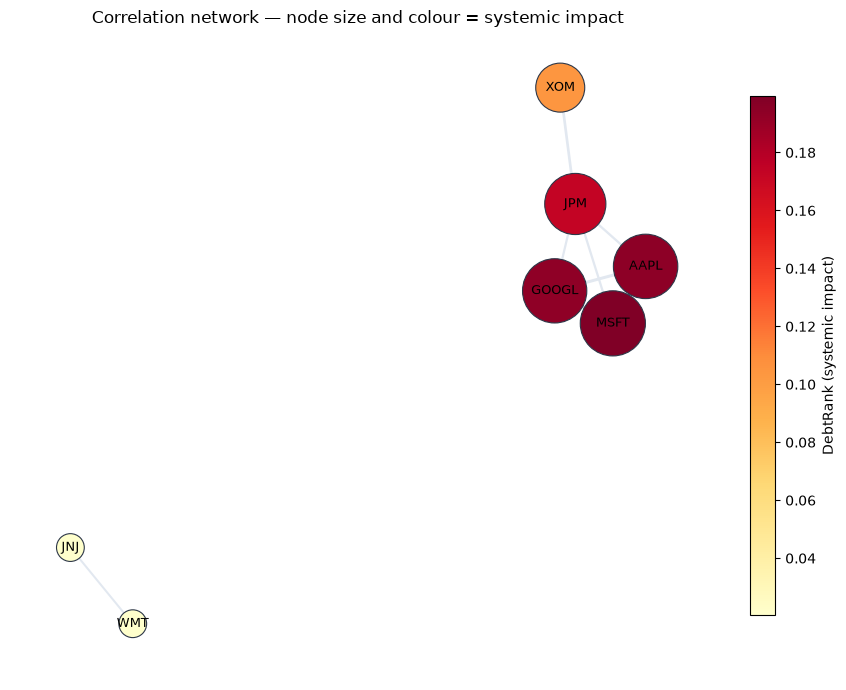

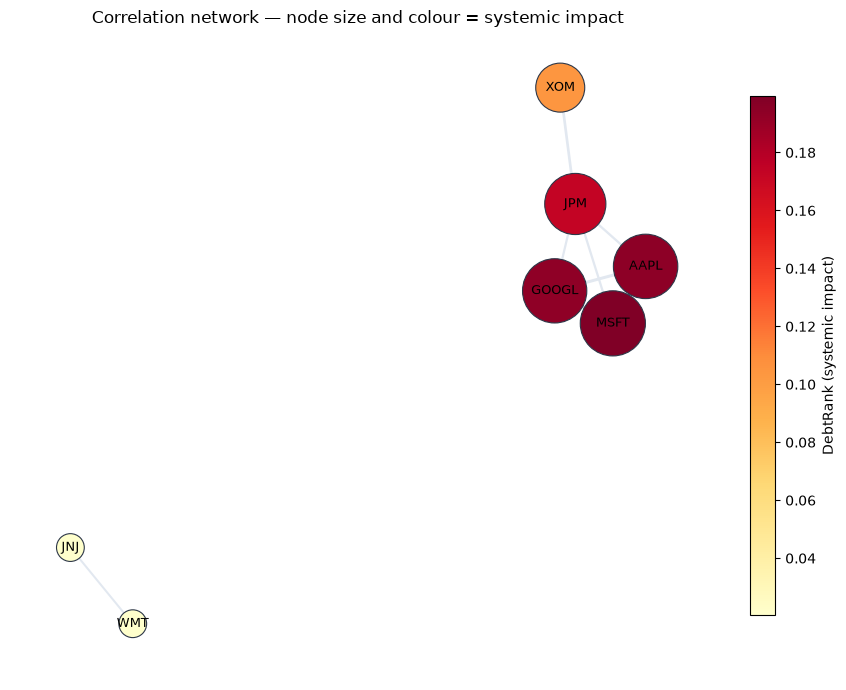

In [6]:
plot_network(g_thresh, systemic)

## Value weighting

Systemic importance depends on position size, not only on connectivity. A large
holding transmits more distress than an identically-connected small one.

In [7]:
equal = {t: 1.0 for t in TICKERS}
concentrated = dict(equal, JPM=10.0)

for label, values in [("equal weights", equal), ("10x JPM", concentrated)]:
    r = debt_rank(g_thresh, "JPM", 0.30, values=values)
    print(f"{label:<15} total loss = {r.total_loss:.4f}   DebtRank = {r.debt_rank:.4f}")

equal weights   total loss = 0.2163   DebtRank = 0.1734
10x JPM         total loss = 0.3656   DebtRank = 0.1781


## Honest limitations

- **Correlation is not causation.** This network measures co-movement, not
  contractual exposure. A true interbank DebtRank uses a liabilities matrix;
  correlation is the best available proxy for a securities portfolio.
- **Correlations are unstable** — they rise sharply in crises, exactly when the
  model matters most. A rolling-window version would show this.
- The 30% shock size is a scenario choice, not an estimate.